In [11]:

# No terminal, uma vez: python -m pip install xlrd pandas
import pandas as pd



In [12]:
path = r"H:\3° Ano\Python\3° Etapa\analise_dados\Tabela 1.1.1.xls"

In [13]:
indicador_1 = pd.read_excel(path, engine="xlrd")

In [14]:
indicador_1


,"Tabela 1.1.1 - Número médio de horas semanais dedicadas aos cuidados de pessoas e/ou afazeres domésticos das pessoas de 14 anos ou mais de idade, na semana de referência, por sexo e cor ou raça, segundo Grandes Regiões e Unidades da Federação - Brasil - 2022",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Grandes Regiões e Unidades da Federação,Número médio de horas semanais dedicadas aos c...,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Total,Por sexo e cor ou raça,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,Total,NaN,Homem,NaN,Mulher,NaN
6,NaN,NaN,Branca,Preta ou parda,Branca,Preta ou parda,Branca,Preta ou parda
7,Brasil,16.985781,16.54593,17.333142,11.705136,11.74633,20.404106,22.037998
8,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.29578,20.534188
9,Rondônia,17.014162,16.727733,17.101523,12.111127,12.54408,20.412887,21.06141


O `.xls` do IBGE mistura **título**, cabeçalho em várias linhas e **notas no rodapé**.  
Cortamos isso e deixamos só: **nomes das colunas + números**.

Tabela 1.1.1 - Número médio de horas semanais dedicadas aos cuidados de pessoas e/ou afazeres domésticos das pessoas de 14 anos ou mais de idade, na semana de referência, por sexo e cor ou raça, segundo Grandes Regiões e Unidades da Federação - Brasil - 2022	

In [15]:
# Lê sem usar a 1ª linha como nome de coluna (senão o título vira "coluna")
bruto = pd.read_excel(path, engine="xlrd", header=None)

# Linhas 0–7: título/cabeçalho  |  8–40: resultados  |  41+: fonte e notas
indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

# horas são número, não texto
for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

indicador_1


,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Brasil,16.985781,16.545930,17.333142,11.705136,11.746330,20.404106,22.037998
1,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
9,Nordeste,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716


In [16]:
# Média nacional = linha Brasil (dado do IBGE), não a média das linhas da tabela
media_nacional = indicador_1.loc[indicador_1["uf_regiao"] == "Brasil", "total"].item()
media_nacional

16.985780816563242

In [17]:
media_nacional

16.985780816563242

Qual(is) estado(s) está acima da média nacional de afazeres domésticos?

In [18]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]

acima_media = estados.loc[
    estados["total"] > media_nacional,
    ["uf_regiao", "total"],
].sort_values("total", ascending=False)

print(f"Média nacional (Brasil): {media_nacional:.2f} horas/semana")
print(f"Estados acima da média: {len(acima_media)}")
acima_media

Média nacional (Brasil): 16.99 horas/semana
Estados acima da média: 12


,uf_regiao,total
16,Alagoas,20.217129
12,Ceará,19.499293
15,Pernambuco,19.306249
14,Paraíba,18.920816
17,Sergipe,18.826541
13,Rio Grande do Norte,18.307740
11,Piauí,17.960366
18,Bahia,17.849776
20,Minas Gerais,17.502141
21,Espírito Santo,17.111106


Quais estados estão abaixo da média?

In [19]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]

abaixo_media = estados.loc[
    estados["total"] < media_nacional,
    ["uf_regiao", "total"],
].sort_values("total", ascending=False)

print(f"Média nacional (Brasil): {media_nacional:.2f} horas/semana")
print(f"Estados abaixo da média: {len(abaixo_media)}")
abaixo_media

Média nacional (Brasil): 16.99 horas/semana
Estados abaixo da média: 15


,uf_regiao,total
4,Amazonas,16.807290
22,Rio de Janeiro,16.716263
10,Maranhão,16.669614
6,Pará,16.474268
26,Santa Catarina,16.039355
8,Tocantins,15.815781
25,Paraná,15.390122
27,Rio Grande do Sul,15.356709
29,Mato Grosso do Sul,15.309783
31,Goiás,15.186471


Qual é o percentual de diferença no Brasil que mulheres trabalham mais que homens em casa?

In [20]:

brasil = indicador_1.loc[indicador_1["uf_regiao"] == "Brasil"].iloc[0]

homem = (brasil["homem_branca"] + brasil["homem_preta_parda"]) / 2
mulher = (brasil["mulher_branca"] + brasil["mulher_preta_parda"]) / 2

# quanto % a mais as mulheres trabalham em relação aos homens
percentual = (mulher - homem) / homem * 100

print(f"Homens (média das cores):   {homem:.2f} h/semana")
print(f"Mulheres (média das cores): {mulher:.2f} h/semana")
print(f"Mulheres trabalham {percentual:.1f}% a mais que homens em casa, no Brasil.")

# recorte por cor (a tabela traz isso de fato)
perc_branca = (brasil["mulher_branca"] / brasil["homem_branca"] - 1) * 100
perc_preta_parda = (brasil["mulher_preta_parda"] / brasil["homem_preta_parda"] - 1) * 100
print(f"Branca:        mulheres +{perc_branca:.1f}%")
print(f"Preta ou parda: mulheres +{perc_preta_parda:.1f}%")


Homens (média das cores):   11.73 h/semana
Mulheres (média das cores): 21.22 h/semana
Mulheres trabalham 81.0% a mais que homens em casa, no Brasil.
Branca:        mulheres +74.3%
Preta ou parda: mulheres +87.6%


Agora responda:
- Quantas horas mulheres pretas trabalham a mais que mulheres brancas em Minas Gerais? Em MG, mulheres pretas trabalham 0.89 horas a mais que mulheres brancas.
- Quantas horas mulheres pretas trabalham a mais que homens brancos no Brasil? No Brasil, mulheres pretas trabalham 10.33 horas a mais que homens brancos.
- Quantas horas mulheres pretas trabalham a mais que mulheres brancas no Amapá? No Amapá, mulheres pretas trabalham -0.74 horas a mais que mulheres brancas.


In [21]:
mg = indicador_1.loc[indicador_1["uf_regiao"] == "Minas Gerais"].iloc[0]

dif_horas_mg = mg["mulher_preta_parda"] - mg["mulher_branca"]
print(f"Em MG, mulheres pretas trabalham {dif_horas_mg:.2f} horas a mais que mulheres brancas.")

Em MG, mulheres pretas trabalham 0.89 horas a mais que mulheres brancas.


In [22]:
dif_horas_br = brasil["mulher_preta_parda"] - brasil["homem_branca"]
print(f"No Brasil, mulheres pretas trabalham {dif_horas_br:.2f} horas a mais que homens brancos.")

No Brasil, mulheres pretas trabalham 10.33 horas a mais que homens brancos.


In [23]:
ap = indicador_1.loc[indicador_1["uf_regiao"] == "Amapá"].iloc[0]

dif_horas_ap = ap["mulher_preta_parda"] - ap["mulher_branca"]
print(f"No Amapá, mulheres pretas trabalham {dif_horas_ap:.2f} horas a mais que mulheres brancas.")

No Amapá, mulheres pretas trabalham -0.74 horas a mais que mulheres brancas.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", palette="Set2")

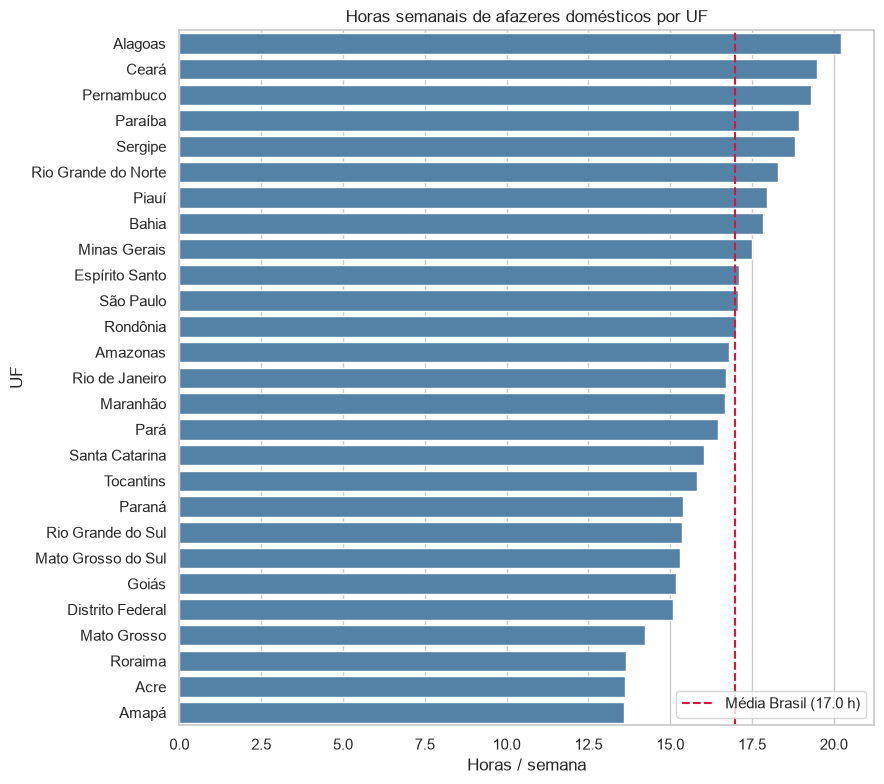

In [25]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)].copy()

# Barras horizontais: horas totais por UF (ordenado)
fig, ax = plt.subplots(figsize=(9, 8))
ordem = estados.sort_values("total", ascending=False)
sns.barplot(data=ordem, y="uf_regiao", x="total", ax=ax, color="steelblue")
ax.axvline(
    media_nacional,
    color="crimson",
    linestyle="--",
    label=f"Média Brasil ({media_nacional:.1f} h)",
)
ax.set_title("Horas semanais de afazeres domésticos por UF")
ax.set_xlabel("Horas / semana")
ax.set_ylabel("UF")
ax.legend()
plt.tight_layout()
plt.show()

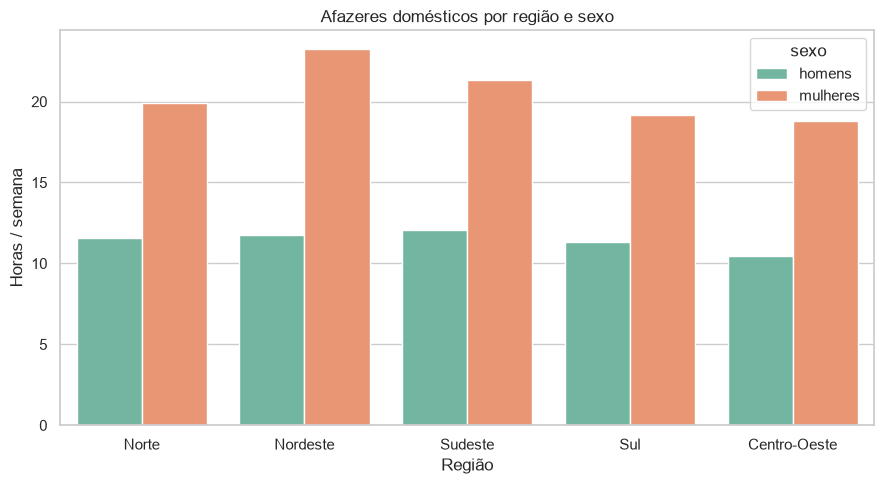

In [26]:
# Barras agrupadas: homens x mulheres por grande região
reg = indicador_1[indicador_1["uf_regiao"].isin(regioes)].copy()
reg["homens"] = (reg["homem_branca"] + reg["homem_preta_parda"]) / 2
reg["mulheres"] = (reg["mulher_branca"] + reg["mulher_preta_parda"]) / 2
reg_long = reg.melt(
    id_vars="uf_regiao",
    value_vars=["homens", "mulheres"],
    var_name="sexo",
    value_name="horas",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=reg_long, x="uf_regiao", y="horas", hue="sexo", ax=ax)
ax.set_title("Afazeres domésticos por região e sexo")
ax.set_xlabel("Região")
ax.set_ylabel("Horas / semana")
plt.tight_layout()
plt.show()

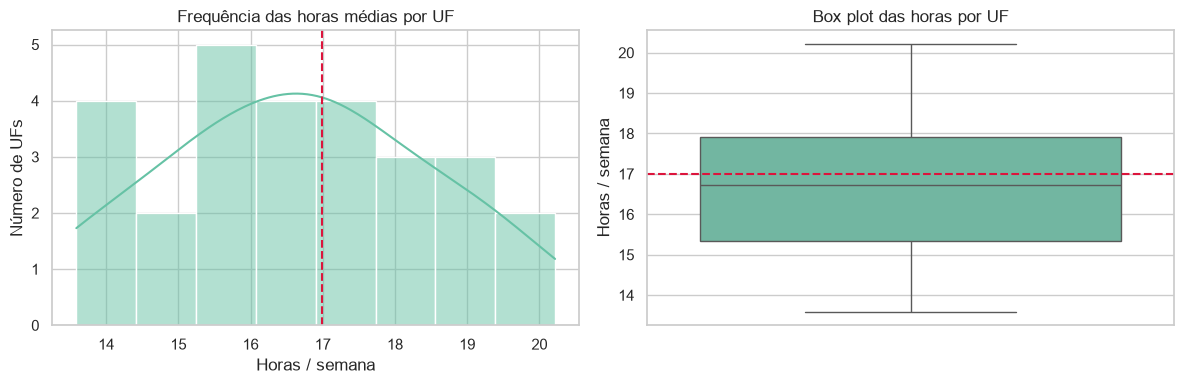

In [27]:
# Histograma (frequência) e box plot das horas por UF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(estados["total"], bins=8, kde=True, ax=axes[0])
axes[0].axvline(media_nacional, color="crimson", linestyle="--")
axes[0].set_title("Frequência das horas médias por UF")
axes[0].set_xlabel("Horas / semana")
axes[0].set_ylabel("Número de UFs")

sns.boxplot(y=estados["total"], ax=axes[1])
axes[1].axhline(media_nacional, color="crimson", linestyle="--")
axes[1].set_title("Box plot das horas por UF")
axes[1].set_ylabel("Horas / semana")
plt.tight_layout()
plt.show()


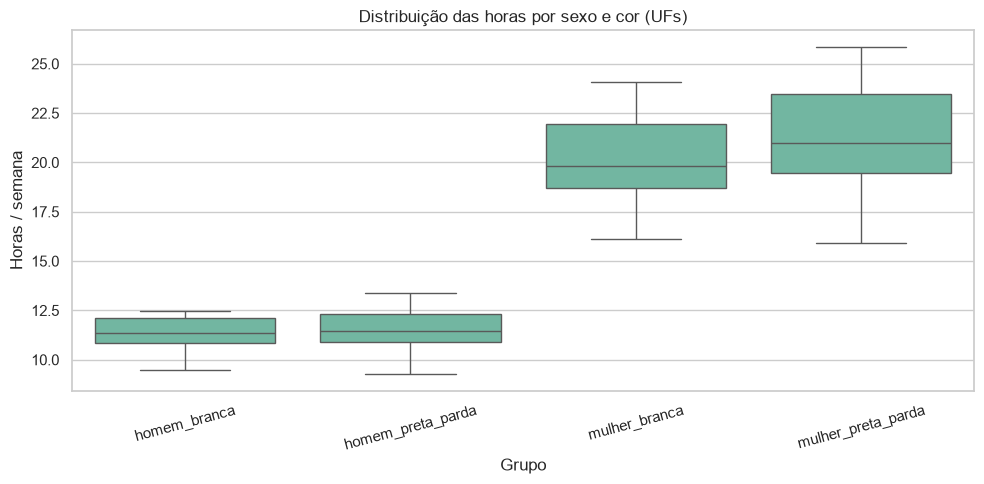

In [28]:
# Box plot: distribuição por sexo e cor (cada ponto/caixa usa as 27 UFs)
box_df = estados[
    ["homem_branca", "homem_preta_parda", "mulher_branca", "mulher_preta_parda"]
].melt(var_name="grupo", value_name="horas")

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=box_df, x="grupo", y="horas", ax=ax)
ax.set_title("Distribuição das horas por sexo e cor (UFs)")
ax.set_xlabel("Grupo")
ax.set_ylabel("Horas / semana")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()